# 02. Feature Engineering

초기 100사이클에서 셀별 `log_delta_q_variance`와 `mean_chargetime`을 생성합니다. Target이 없는 셀은 제외하며, Batch 1은 학습용, Batch 2·3은 외부 평가용으로 유지합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    FEATURE_COLUMNS,
    build_feature_table,
    save_feature_table,
)
from src.preprocess import load_all_batches

FEATURE_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'battery_features.csv'
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 피처 생성

대용량 MAT 파일 전체를 메모리에 올리지 않고 Target, 초기 충전 시간, 10·100사이클 Qdlin만 읽습니다.

In [2]:
cells = load_all_batches()
feature_df = build_feature_table(cells)
save_feature_table(feature_df, FEATURE_OUTPUT)

print(f'피처 파일 저장: {FEATURE_OUTPUT}')
print(f'전체 유효 셀: {len(feature_df)}')
display(feature_df.head())

Batch 1 로딩 완료: 46 cells
Batch 2 로딩 완료: 47 cells
Batch 3 로딩 완료: 46 cells
피처 파일 저장: /Users/sonsugyung/skala/11th_week/data-mini-prj/data/processed/battery_features.csv
전체 유효 셀: 129


,batch,cell_id,cell_key,cycle_life,log_delta_q_variance,mean_chargetime
0,Batch 1,0,Batch 1-C00,1190.0,-5.014427,13.250388
1,Batch 1,1,Batch 1-C01,1179.0,-5.013525,13.240949
2,Batch 1,2,Batch 1-C02,1177.0,-4.736565,13.245097
3,Batch 1,3,Batch 1-C03,1226.0,-4.442179,11.932744
4,Batch 1,4,Batch 1-C04,1227.0,-4.647309,11.932781


## 품질 확인

셀 중복, 결측값, Batch별 표본 수를 확인합니다. 결측값 대체가 필요할 경우 실제 모델 Pipeline에서 Batch 1 학습 fold만 사용해 처리합니다.

In [3]:
quality_summary = (
    feature_df.groupby('batch', observed=True)
    .agg(
        cells=('cell_key', 'count'),
        cycle_life_min=('cycle_life', 'min'),
        cycle_life_mean=('cycle_life', 'mean'),
        cycle_life_max=('cycle_life', 'max'),
        log_variance_mean=('log_delta_q_variance', 'mean'),
        chargetime_mean=('mean_chargetime', 'mean'),
    )
)
display(quality_summary.round(4))

print('열별 결측값')
display(feature_df.isna().sum().to_frame('missing_count'))
print('중복 셀:', feature_df.duplicated(['batch', 'cell_key']).sum())

,cells,cycle_life_min,cycle_life_mean,cycle_life_max,log_variance_mean,chargetime_mean
batch,,,,,,
Batch 1,46,534.0,844.7174,1227.0,-3.9230,11.1683
Batch 2,39,392.0,565.7436,1186.0,-3.5958,20.2103
Batch 3,44,541.0,1059.6591,1935.0,-4.1938,10.1816


열별 결측값


,missing_count
batch,0
cell_id,0
cell_key,0
cycle_life,0
log_delta_q_variance,0
mean_chargetime,0


중복 셀: 0


## 피처와 Cycle Life의 관계

모델 선택 근거를 확인하기 위해 Batch별 산점도와 Pearson 상관계수를 표시합니다.

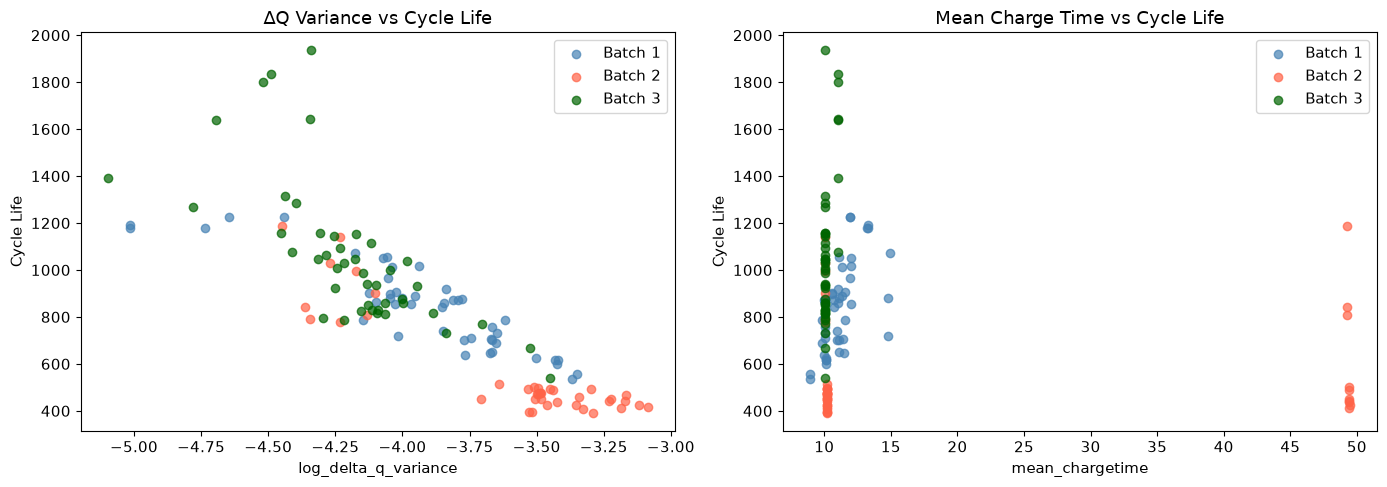

,batch,feature,pearson_r
0,Batch 1,log_delta_q_variance,-0.886
1,Batch 1,mean_chargetime,0.577
2,Batch 2,log_delta_q_variance,-0.902
3,Batch 2,mean_chargetime,0.087
4,Batch 3,log_delta_q_variance,-0.702
5,Batch 3,mean_chargetime,0.637


In [4]:
batch_colors = {
    'Batch 1': 'steelblue',
    'Batch 2': 'tomato',
    'Batch 3': 'darkgreen',
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for batch_name, batch_data in feature_df.groupby('batch', observed=True):
    color = batch_colors[batch_name]
    for axis, feature_name in zip(axes, FEATURE_COLUMNS):
        axis.scatter(
            batch_data[feature_name],
            batch_data['cycle_life'],
            color=color, alpha=0.7, label=batch_name,
        )
        axis.set_xlabel(feature_name)
        axis.set_ylabel('Cycle Life')

axes[0].set_title('ΔQ Variance vs Cycle Life')
axes[1].set_title('Mean Charge Time vs Cycle Life')
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

correlation_records = []
for batch_name, batch_data in feature_df.groupby('batch', observed=True):
    for feature_name in FEATURE_COLUMNS:
        correlation_records.append({
            'batch': batch_name,
            'feature': feature_name,
            'pearson_r': batch_data[feature_name].corr(
                batch_data['cycle_life']
            ),
        })
display(pd.DataFrame(correlation_records).round(3))

## 모델 입력 확정

- `log_delta_q_variance`: 초기 열화 신호, Batch 1에서 Cycle Life와 강한 음의 선형 관계
- `mean_chargetime`: 충전 속도·조건 신호, Batch 1에서 Cycle Life와 양의 관계
- 학습 표본이 46개이므로 최종 입력은 두 피처로 제한
- `batch`, `cell_id`, `cell_key`는 식별자이며 모델 입력에서 제외
- Knee point는 전체 수명 정보이므로 모델 입력에서 제외